# **Smart Predictive Maintenance System using Machine Learning**

# **Project Overview**
**This project develops a machine learning-based predictive maintenance system for smart manufacturing. Using IoT sensor data collected from industrial machines, the system predicts whether a machine requires maintenance, identifies the expected failure type, and estimates its remaining useful life (RUL). The objective is to help reduce unexpected downtime, optimize maintenance scheduling, and improve operational efficiency.**

# **Project Objectives**

- Predict whether a machine requires maintenance.
- Identify the expected failure type.
- Estimate the Remaining Useful Life (RUL) of the machine.
- Analyze IoT sensor data to discover patterns related to equipment failures.

# **Dataset Description**

**The dataset contains 100,000 IoT sensor records collected from industrial machines in a smart manufacturing environment.**

## Features

 **- Timestamp
- Machine ID
- Temperature
- Vibration
- Humidity
- Pressure
- Energy Consumption
- Machine Status
- Anomaly Flag
- Predicted Remaining Life
- Failure Type
- Downtime Risk
- Maintenance Required**

# importing libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import *
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings("ignore")

#Load Dataset

In [2]:
!kaggle datasets download -d ziya07/smart-manufacturing-iot-cloud-monitoring-dataset

Dataset URL: https://www.kaggle.com/datasets/ziya07/smart-manufacturing-iot-cloud-monitoring-dataset
License(s): CC0-1.0
smart-manufacturing-iot-cloud-monitoring-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [3]:
!unzip smart-manufacturing-iot-cloud-monitoring-dataset.zip

Archive:  smart-manufacturing-iot-cloud-monitoring-dataset.zip
replace smart_manufacturing_data.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: smart_manufacturing_data.csv  


In [4]:

data = pd.read_csv("smart_manufacturing_data.csv")

# Data Explore

In [5]:
data.sample(10)

,timestamp,machine_id,temperature,vibration,humidity,pressure,energy_consumption,machine_status,anomaly_flag,predicted_remaining_life,failure_type,downtime_risk,maintenance_required
55232,2025-02-08 08:32:00,41,66.95,56.97,53.24,2.92,3.27,1,0,465,Normal,0.0,0
68053,2025-02-17 06:13:00,26,78.66,60.16,31.01,1.24,4.14,1,0,101,Normal,0.0,0
12635,2025-01-09 18:35:00,43,84.88,40.10,71.15,1.46,2.87,1,0,483,Normal,0.0,0
69377,2025-02-18 04:17:00,21,89.77,68.62,62.23,1.88,1.34,1,0,22,Normal,0.0,0
28929,2025-01-21 02:09:00,33,51.44,83.55,47.54,4.75,0.82,2,1,21,Pressure Drop,1.0,1
64370,2025-02-14 16:50:00,12,85.31,42.45,56.60,4.98,4.50,1,0,360,Normal,0.0,0
53090,2025-02-06 20:50:00,48,89.35,27.84,38.43,2.26,2.57,1,0,424,Normal,0.0,0
66974,2025-02-16 12:14:00,14,87.54,40.11,72.22,1.11,2.75,1,0,344,Normal,0.0,0
86383,2025-03-01 23:43:00,37,79.70,52.75,51.07,1.58,1.50,2,0,166,Vibration Issue,0.0,1
56382,2025-02-09 03:42:00,28,90.35,56.38,30.95,2.92,2.86,2,1,45,Pressure Drop,1.0,1


In [6]:
data.shape

(100000, 13)

In [7]:
data.columns

Index(['timestamp', 'machine_id', 'temperature', 'vibration', 'humidity',
       'pressure', 'energy_consumption', 'machine_status', 'anomaly_flag',
       'predicted_remaining_life', 'failure_type', 'downtime_risk',
       'maintenance_required'],
      dtype='object')

In [8]:
data.dtypes

,0
timestamp,object
machine_id,int64
temperature,float64
vibration,float64
humidity,float64
pressure,float64
energy_consumption,float64
machine_status,int64
anomaly_flag,int64
predicted_remaining_life,int64


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   timestamp                 100000 non-null  object 
 1   machine_id                100000 non-null  int64  
 2   temperature               100000 non-null  float64
 3   vibration                 100000 non-null  float64
 4   humidity                  100000 non-null  float64
 5   pressure                  100000 non-null  float64
 6   energy_consumption        100000 non-null  float64
 7   machine_status            100000 non-null  int64  
 8   anomaly_flag              100000 non-null  int64  
 9   predicted_remaining_life  100000 non-null  int64  
 10  failure_type              100000 non-null  object 
 11  downtime_risk             100000 non-null  float64
 12  maintenance_required      100000 non-null  int64  
dtypes: float64(6), int64(5), object(2)
memory usa

In [10]:
data.describe()

,machine_id,temperature,vibration,humidity,pressure,energy_consumption,machine_status,anomaly_flag,predicted_remaining_life,downtime_risk,maintenance_required
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,25.499330,75.015625,50.012270,54.995401,3.000405,2.747064,1.002050,0.089160,234.269160,0.089155,0.196970
std,14.389439,10.031884,14.985444,14.437960,1.152399,1.297865,0.446193,0.284976,150.063062,0.284961,0.397711
min,1.000000,35.550000,-17.090000,30.000000,1.000000,0.500000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,13.000000,68.267500,39.970000,42.520000,2.000000,1.630000,1.000000,0.000000,97.000000,0.000000,0.000000
50%,25.000000,75.060000,49.960000,54.980000,3.010000,2.740000,1.000000,0.000000,230.000000,0.000000,0.000000
75%,38.000000,81.750000,60.100000,67.500000,4.000000,3.870000,1.000000,0.000000,365.000000,0.000000,0.000000
max,50.000000,121.940000,113.800000,80.000000,5.000000,5.000000,2.000000,1.000000,499.000000,1.000000,1.000000


In [11]:
data.isnull().sum()

,0
timestamp,0
machine_id,0
temperature,0
vibration,0
humidity,0
pressure,0
energy_consumption,0
machine_status,0
anomaly_flag,0
predicted_remaining_life,0


In [12]:
data.duplicated().sum()

np.int64(0)

#Exploratory Data Analysis (EDA)

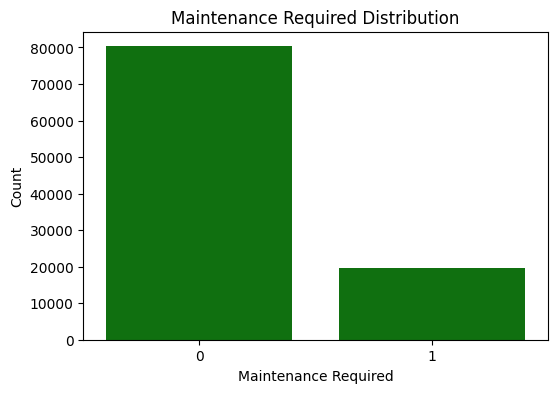

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(x='maintenance_required', data=data,color='green')

plt.title("Maintenance Required Distribution")
plt.xlabel("Maintenance Required")
plt.ylabel("Count")

plt.show()

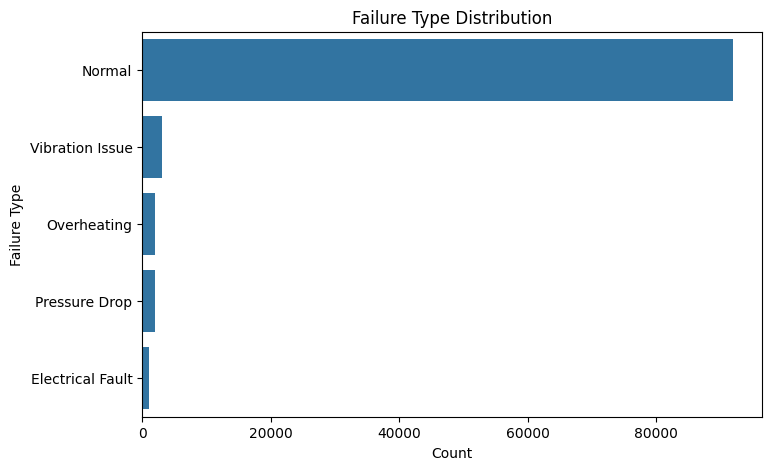

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(
    y='failure_type',
    data=data,
    order=data['failure_type'].value_counts().index
)

plt.title("Failure Type Distribution")
plt.xlabel("Count")
plt.ylabel("Failure Type")

plt.show()

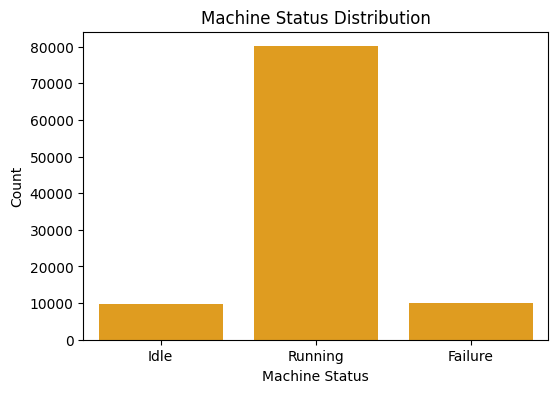

In [15]:
plt.figure(figsize=(6,4))

ax = sns.countplot(x='machine_status', data=data,color='orange')

ax.set_xticklabels(['Idle', 'Running', 'Failure'])

plt.title("Machine Status Distribution")
plt.xlabel("Machine Status")
plt.ylabel("Count")

plt.show()


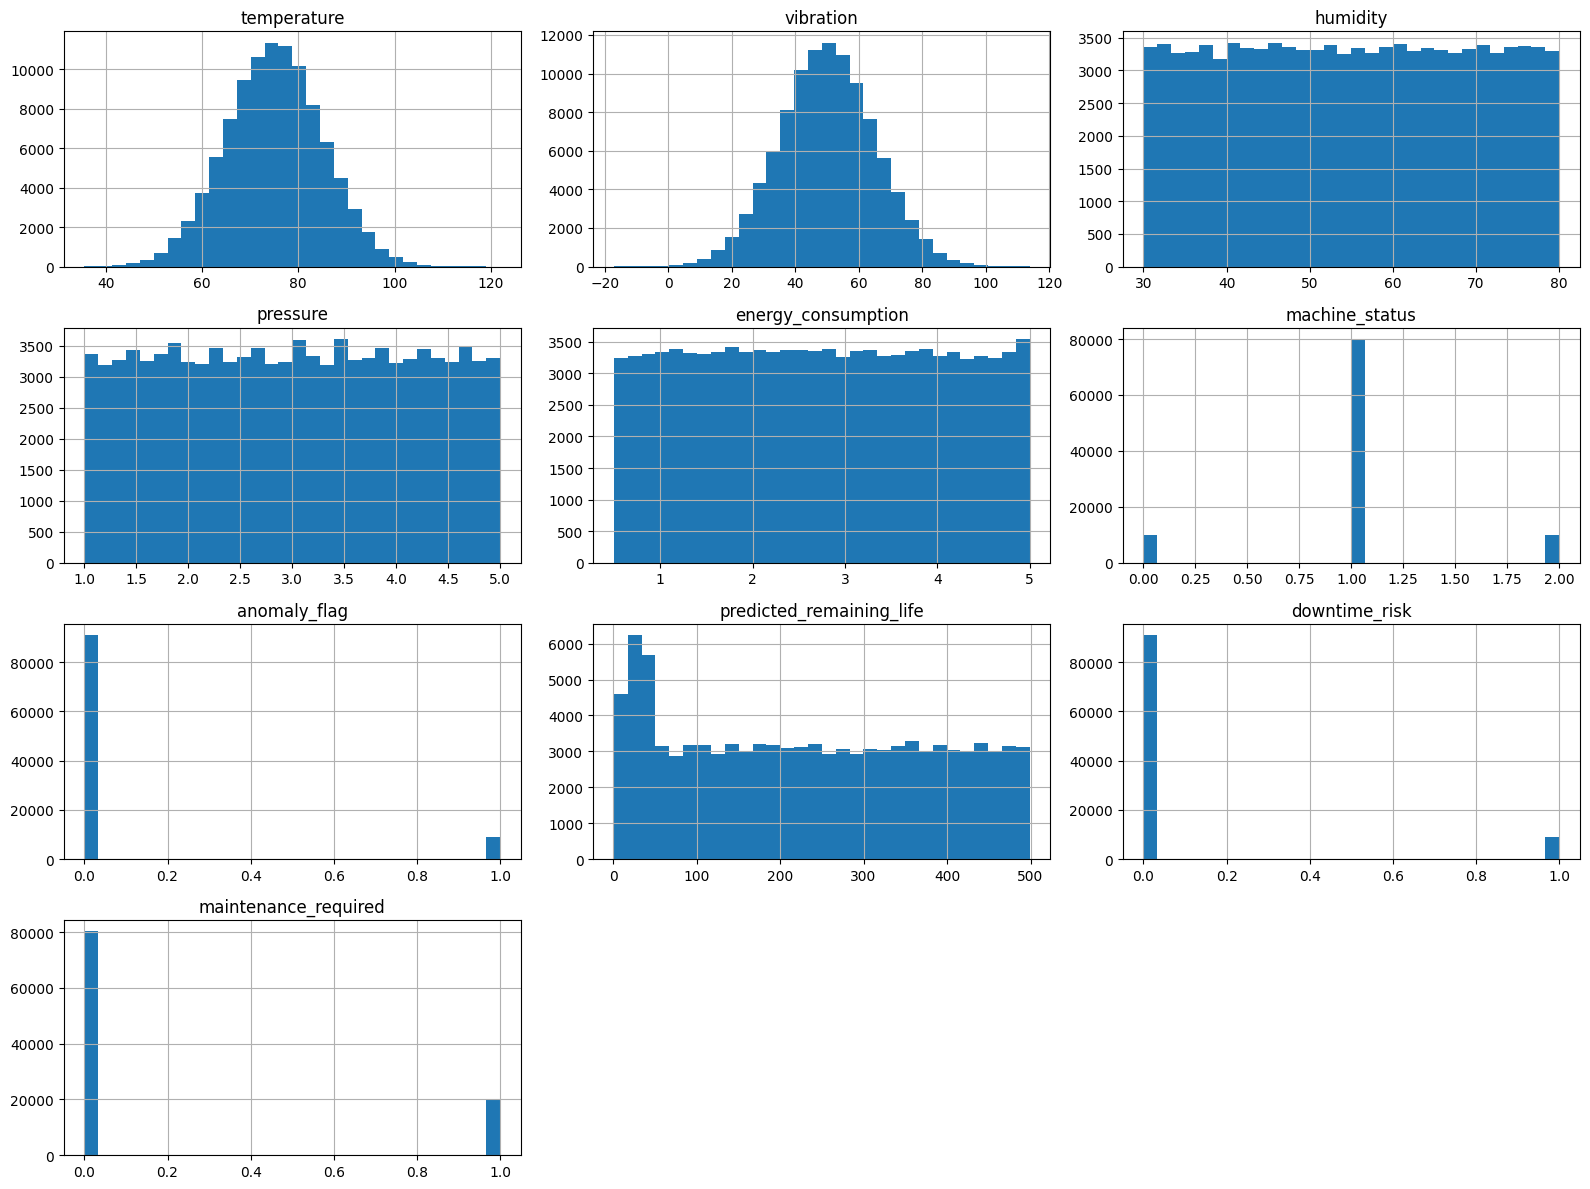

In [16]:
num_cols = data.select_dtypes(include=['int64', 'float64']).columns

num_cols = num_cols.drop('machine_id')

data[num_cols].hist(figsize=(16,12), bins=30 )

plt.tight_layout()
plt.show()

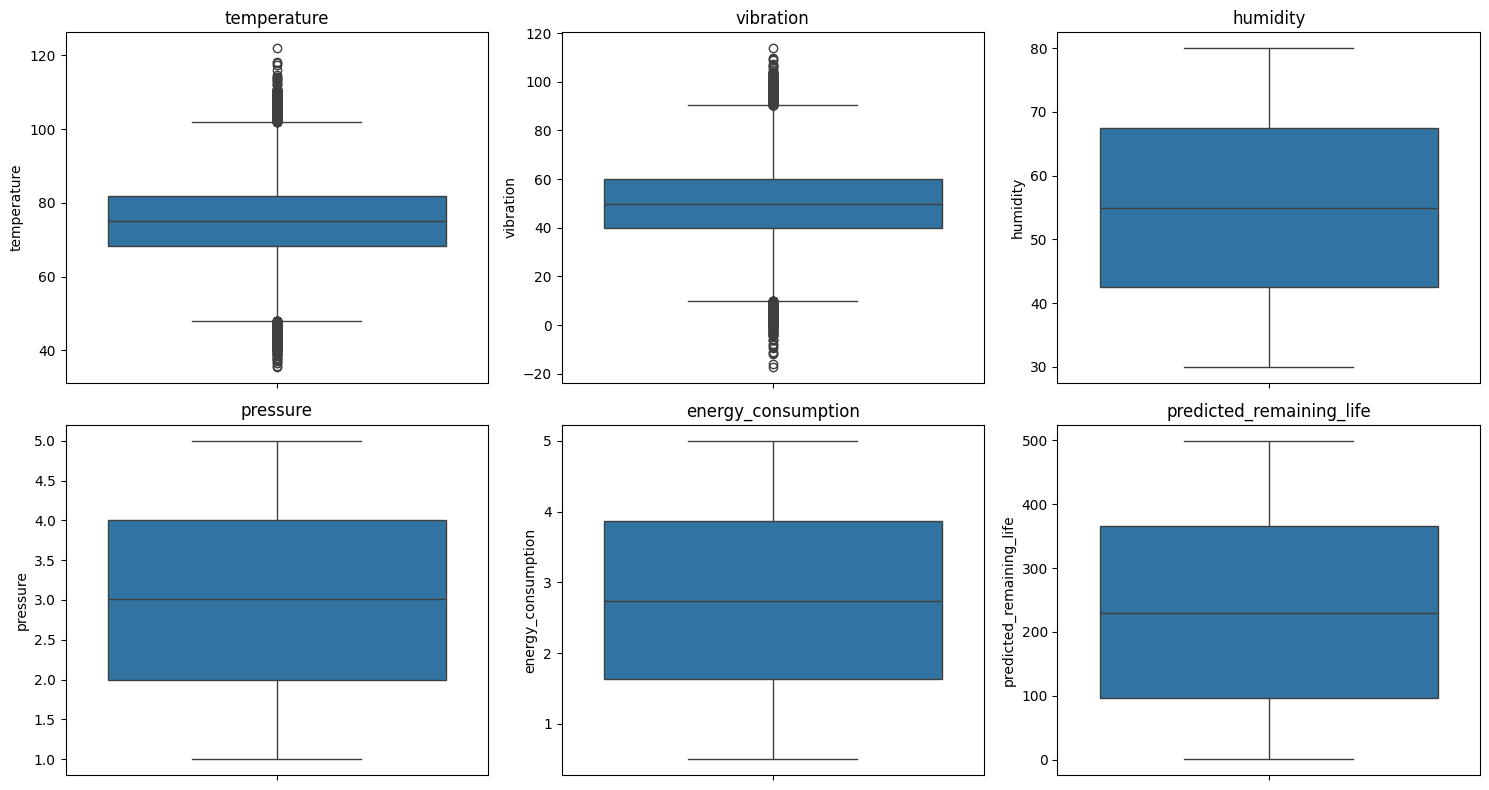

In [17]:
cols = [
    'temperature',
    'vibration',
    'humidity',
    'pressure',
    'energy_consumption',
    'predicted_remaining_life'
]

plt.figure(figsize=(15, 8))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=data[col])
    plt.title(col)

plt.tight_layout()
plt.show()

#Temperature and vibration contain a small number of outliers. Since these values may represent abnormal machine behavior rather than data entry errors, they will be retained for model training.


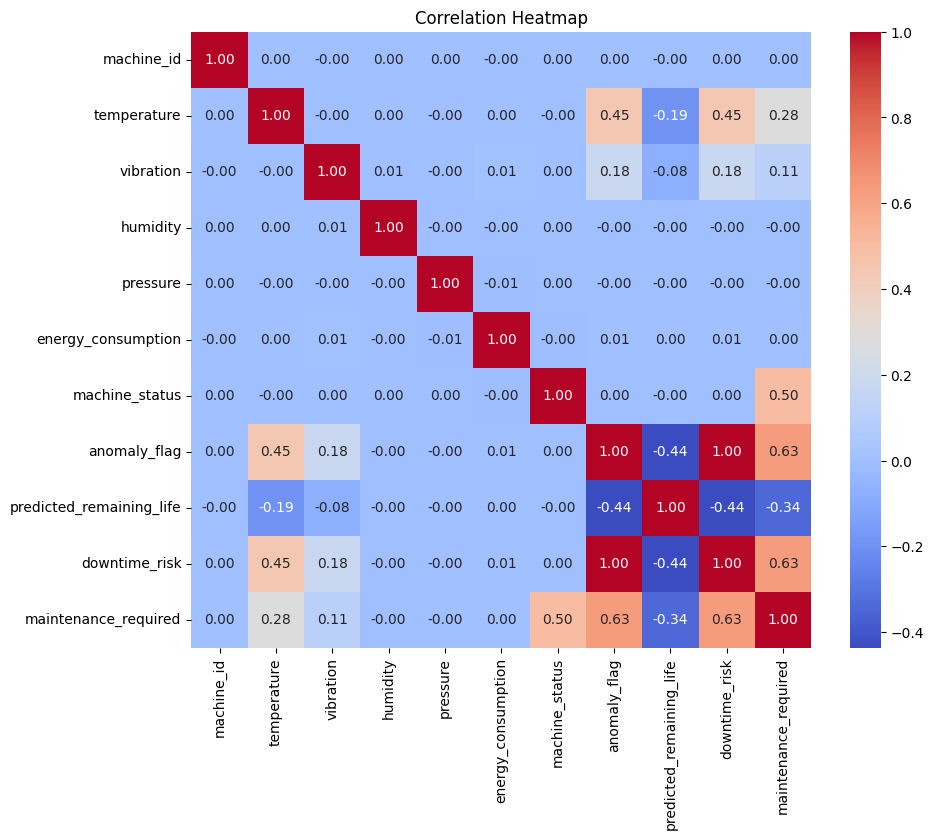

In [18]:
plt.figure(figsize=(10,8))

sns.heatmap(
    data.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

# Observations

- **Maintenance Required** shows the strongest positive correlation with **Anomaly Flag (0.63)** and **Downtime Risk (0.63)**.
- **Machine Status** has a moderate positive correlation (0.50) with **Maintenance Required**, indicating that the machine's operating state is related to maintenance needs.
- **Predicted Remaining Life** has a moderate negative correlation (-0.34) with **Maintenance Required**, meaning machines with less remaining life are more likely to require maintenance.
- **Temperature** has a weak positive correlation (0.28) with **Maintenance Required**, suggesting that higher temperatures may increase the likelihood of maintenance.
- **Vibration** has a very weak positive correlation (0.11) with **Maintenance Required**.
- **Humidity**, **Pressure**, **Energy Consumption**, and **Machine ID** show little to no linear correlation with the target variable.
- Some features have strong correlations with each other (e.g., **Anomaly Flag** and **Downtime Risk**), which should be considered during feature selection to avoid data leakage.

#**Data preprocessing**

In [19]:
data['timestamp'] = pd.to_datetime(data['timestamp'])
data['hour'] = data['timestamp'].dt.hour
data['day'] = data['timestamp'].dt.day
data['month'] = data['timestamp'].dt.month
data['day_of_week'] = data['timestamp'].dt.dayofweek
data = data.drop(columns=['timestamp'])

In [20]:
le = LabelEncoder()

data['failure_type'] = le.fit_transform(data['failure_type'])

#**Create Dataset for Maintenance Prediction**

In [21]:
maintenance_data = data.drop(
    columns=[
        'maintenance_required',
        'failure_type',
        'predicted_remaining_life',
        'anomaly_flag',
        'downtime_risk'
    ]
)

X = maintenance_data
y = data['maintenance_required']

# Data split

In [22]:
X = X.drop(columns=['machine_id'])

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [24]:
scaler = StandardScaler()

numeric_cols = [
    'temperature',
    'vibration',
    'humidity',
    'pressure',
    'energy_consumption'
]

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [52]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [53]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
maintenance_required
0    64242
1    15758
Name: count, dtype: int64

After SMOTE:
maintenance_required
0    64242
1    64242
Name: count, dtype: int64


# **Train Multiple Models**

In [54]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),

    "XGBoost": XGBClassifier(random_state=42)
}

# **Compare Models**

# Results

In [55]:

results = []

best_model = None
best_name = None
best_f1 = 0

for name, model in models.items():

    model.fit(X_train_smote, y_train_smote)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_prob)
    else:
        roc_auc = None

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": roc_auc
    })


    if f1 > best_f1:
        best_f1 = f1
        best_model = model
        best_name = name

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1 Score", ascending=False)

display(results_df)

print(f"\nBest Model: {best_name}")

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
3,Gradient Boosting,0.97635,0.959926,0.918253,0.938627,0.958982
2,Random Forest,0.97570,0.956625,0.918253,0.937047,0.960087
4,XGBoost,0.97105,0.934783,0.916984,0.925798,0.959198
1,Decision Tree,0.88470,0.643321,0.930439,0.760689,0.901961
0,Logistic Regression,0.80905,0.509172,0.845646,0.635626,0.896696



Best Model: Gradient Boosting


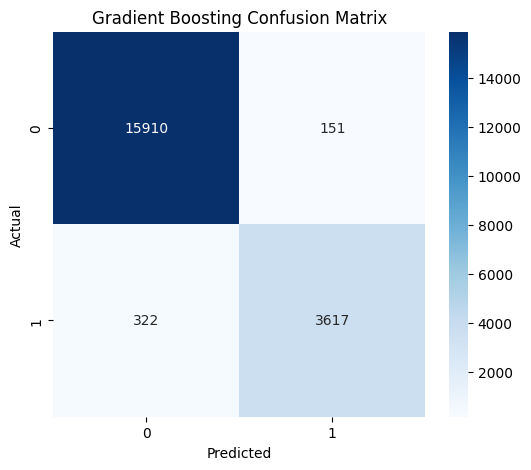

In [56]:
# Predict using best model
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title(f"{best_name} Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Model Selection

Among all evaluated models, **Gradient Boosting** achieved the best balance between training and testing performance. Although Random Forest obtained a slightly higher test accuracy, Gradient Boosting showed almost no performance gap between the training and testing sets, indicating better generalization and a lower risk of overfitting. Therefore, Gradient Boosting was selected as the final model for further evaluation.

In [57]:
best_model = GradientBoostingClassifier(random_state=42)

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

In [58]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_model.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

importance

,Feature,Importance
5,machine_status,0.506034
0,temperature,0.363694
1,vibration,0.129799
2,humidity,0.000222
3,pressure,0.000083
4,energy_consumption,0.000065
7,day,0.000051
8,month,0.000025
6,hour,0.000022
9,day_of_week,0.000005


#**Target 2**

In [59]:
X2 = data.drop(
    columns=[
        'failure_type',
        'maintenance_required',
        'predicted_remaining_life',
        'anomaly_flag',
        'downtime_risk',
        'machine_id'
    ]
)

y2 = data['failure_type']

In [60]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.2,
    random_state=42,
    stratify=y2
)

In [61]:
X2_train[numeric_cols] = scaler.fit_transform(X2_train[numeric_cols])
X2_test[numeric_cols] = scaler.transform(X2_test[numeric_cols])

In [62]:
model2 = {
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),

}

In [63]:
results2 = []

for name, model in model2.items():

    model.fit(X2_train, y2_train)

    train_pred = model.predict(X2_train)
    test_pred = model.predict(X2_test)

    # Train Metrics
    train_acc = accuracy_score(y2_train, train_pred)
    train_precision = precision_score(y2_train, train_pred, average='weighted', zero_division=0)
    train_recall = recall_score(y2_train, train_pred, average='weighted', zero_division=0)
    train_f1 = f1_score(y2_train, train_pred, average='weighted', zero_division=0)

    # Test Metrics
    test_acc = accuracy_score(y2_test, test_pred)
    test_precision = precision_score(y2_test, test_pred, average='weighted', zero_division=0)
    test_recall = recall_score(y2_test, test_pred, average='weighted', zero_division=0)
    test_f1 = f1_score(y2_test, test_pred, average='weighted', zero_division=0)

    results2.append({
        "Model": name,

        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Accuracy Gap": train_acc - test_acc,

        "Train Precision": train_precision,
        "Test Precision": test_precision,
        "Precision Gap": train_precision - test_precision,

        "Train Recall": train_recall,
        "Test Recall": test_recall,
        "Recall Gap": train_recall - test_recall,

        "Train F1": train_f1,
        "Test F1": test_f1,
        "F1 Gap": train_f1 - test_f1
    })

results2_df = pd.DataFrame(results2)
results2_df.sort_values(by="Test F1", ascending=False)

,Model,Train Accuracy,Test Accuracy,Accuracy Gap,Train Precision,Test Precision,Precision Gap,Train Recall,Test Recall,Recall Gap,Train F1,Test F1,F1 Gap
0,Gradient Boosting,0.935025,0.92885,0.006175,0.960692,0.940756,0.019936,0.935025,0.92885,0.006175,0.931412,0.924774,0.006638


#Gradient Boosting achieved the highest test accuracy (92.84%) while maintaining a very small gap (0.71%) between training and testing accuracy, indicating good generalization.

In [64]:
best_failure_model = GradientBoostingClassifier(random_state=42)

best_failure_model.fit(X2_train, y2_train)

y2_pred = best_failure_model.predict(X2_test)

In [65]:
importance = pd.DataFrame({
    'Feature': X2_train.columns,
    'Importance': best_failure_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
5,machine_status,0.962732
1,vibration,0.007920
2,humidity,0.006716
0,temperature,0.006225
4,energy_consumption,0.005394
3,pressure,0.005146
7,day,0.002521
6,hour,0.001981
9,day_of_week,0.000986
8,month,0.000378


In [66]:
def predict_machine(new_data):

    new_data[numeric_cols] = scaler.transform(new_data[numeric_cols])

    maintenance_pred = best_model.predict(new_data)
    failure_pred = best_failure_model.predict(new_data)

    maintenance_result = "Yes" if maintenance_pred[0] == 1 else "No"
    failure_result = le.inverse_transform(failure_pred)[0]

    print("===== Prediction Result =====")
    print("Maintenance Required:", maintenance_result)
    print("Failure Type:", failure_result)

In [67]:
new_data = pd.DataFrame({
    'temperature': [82],
    'vibration': [61],
    'humidity': [45],
    'pressure': [100],
    'energy_consumption': [310],
    'machine_status': [1],
    'hour': [10],
    'day': [15],
    'month': [7],
    'day_of_week': [2]
})

predict_machine(new_data)

===== Prediction Result =====
Maintenance Required: No
Failure Type: Normal


In [68]:
new_data = pd.DataFrame({
    'temperature': [95],
    'vibration': [88],
    'humidity': [30],
    'pressure': [85],
    'energy_consumption': [450],
    'machine_status': [2],
    'hour': [14],
    'day': [20],
    'month': [8],
    'day_of_week': [3]
})

predict_machine(new_data)

===== Prediction Result =====
Maintenance Required: Yes
Failure Type: Electrical Fault
